# House Price Prediction Project

Task 1 - Data loading and Exploration


In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("F:\HousePricePrediction_Vijay_Complete\Housing.csv")

print("Dataset Loaded Successfully")

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
# Number of Rows and Columns

print("Shape of Dataset:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape of Dataset: (545, 13)
Rows: 545
Columns: 13


In [5]:
# Column Names

print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
# Target and Features

target = "price"

features = [col for col in df.columns if col != target]

print("Target Variable:", target)

print("\nFeature Columns:")

for feature in features:
    print(feature)

Target Variable: price

Feature Columns:
area
bedrooms
bathrooms
stories
mainroad
guestroom
basement
hotwaterheating
airconditioning
parking
prefarea
furnishingstatus


In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Task 2 - Data Cleaning

In [10]:
df = df.drop_duplicates()

print("Duplicates Removed")

Duplicates Removed


In [11]:
df = pd.get_dummies(df, drop_first=True)

In [12]:


df = df.dropna()

print("Missing Values Handled")

Missing Values Handled


In [13]:
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)

Index([], dtype='object')


In [14]:
print(df.shape)
print(df.columns.tolist())
print(df.head())

(545, 14)
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False  

# Task 3 - Model Building


In [15]:
print(df.dtypes.value_counts())

bool     8
int64    6
Name: count, dtype: int64


In [16]:
print(df.select_dtypes(include='object').columns)

Index([], dtype='object')


In [17]:
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [18]:
X = df.drop("price", axis=1)
y = df["price"]

print(X.dtypes)
print(X.shape)
print(y.shape)

area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                        bool
guestroom_yes                       bool
basement_yes                        bool
hotwaterheating_yes                 bool
airconditioning_yes                 bool
prefarea_yes                        bool
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object
(545, 13)
(545,)


In [19]:
for col in X.columns:
    print(col, X[col].dtype)

area int64
bedrooms int64
bathrooms int64
stories int64
parking int64
mainroad_yes bool
guestroom_yes bool
basement_yes bool
hotwaterheating_yes bool
airconditioning_yes bool
prefarea_yes bool
furnishingstatus_semi-furnished bool
furnishingstatus_unfurnished bool


In [20]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='object')


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

In [23]:
# Linear Regression Evaluation

lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

print("Linear Regression Results")

print("MAE:", lr_mae)

print("RMSE:", lr_rmse)

print("R2 Score:", lr_r2)

Linear Regression Results
MAE: 970043.4039201637
RMSE: 1324506.9600914388
R2 Score: 0.6529242642153184


In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

print("Success!")

Success!


In [25]:
# Random Forest Model

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

In [26]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.468535
2,bathrooms,0.152554
9,airconditioning_yes,0.060238
4,parking,0.057273
3,stories,0.057064
1,bedrooms,0.047370
12,furnishingstatus_unfurnished,0.036972
7,basement_yes,0.032176
10,prefarea_yes,0.028432
8,hotwaterheating_yes,0.018305


In [27]:
# Random Forest Evaluation

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")

print("MAE:", rf_mae)

print("RMSE:", rf_rmse)

print("R2 Score:", rf_r2)

Random Forest Results
MAE: 1013968.579587156
RMSE: 1398115.6668385956
R2 Score: 0.6132752494107068


In [28]:
print("rf exists:", 'rf' in globals())
print("rf_predictions exists:", 'rf_predictions' in globals())
print("X_train exists:", 'X_train' in globals())
print("y_train exists:", 'y_train' in globals())

rf exists: True
rf_predictions exists: True
X_train exists: True
y_train exists: True


In [29]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


# Task 4 - Visualizations


In [30]:
# Create Charts Folder

import os

os.makedirs(
    "charts",
    exist_ok=True
)

In [31]:
import matplotlib.pyplot as plt

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [33]:
df = pd.read_csv("F:\HousePricePrediction_Vijay_Complete\Housing.csv") 

In [34]:
df_encoded = pd.get_dummies(
    df,
    columns=df.select_dtypes(include='object').columns,
    drop_first=True
)

corr_matrix = df_encoded.corr()

In [35]:
# Clean dataset
df = df.drop_duplicates()
df = df.dropna()

# Encode categorical columns
df = pd.get_dummies(df, drop_first=True)

# Then create heatmap
corr_matrix = df.corr()

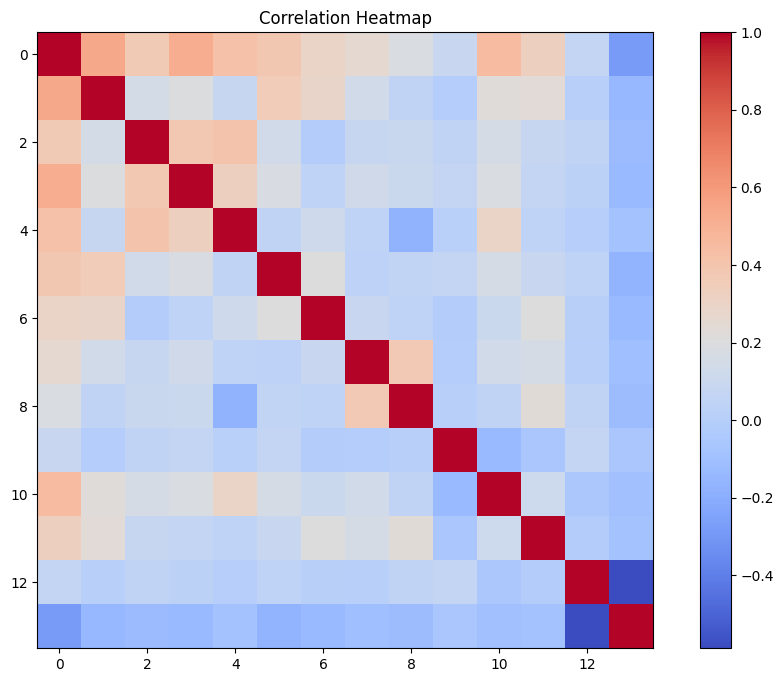

In [36]:
plt.figure(figsize=(12,8))

corr_matrix = df.corr(numeric_only=True)

plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar()

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")

plt.show()

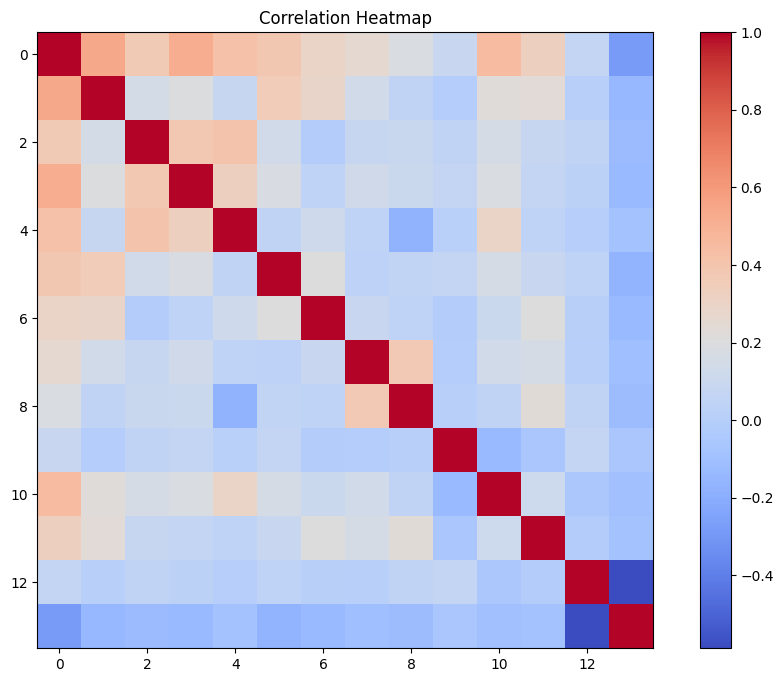

In [37]:
plt.figure(figsize=(12,8))

corr_matrix = df.astype(float).corr()

plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar()

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")

plt.show()

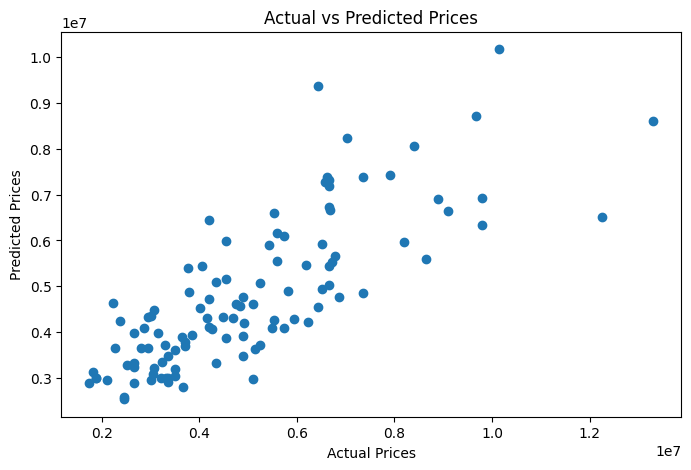

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.savefig("actual_vs_predicted.png")

plt.show()

# Feature Importance Analysis

In [39]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.468535
2,bathrooms,0.152554
9,airconditioning_yes,0.060238
4,parking,0.057273
3,stories,0.057064
1,bedrooms,0.047370
12,furnishingstatus_unfurnished,0.036972
7,basement_yes,0.032176
10,prefarea_yes,0.028432
8,hotwaterheating_yes,0.018305


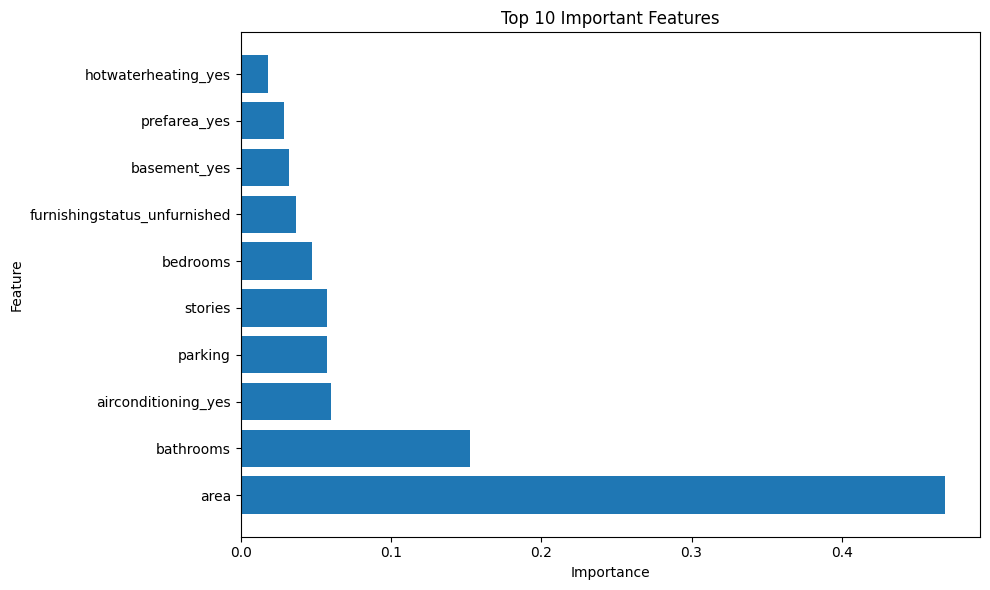

In [40]:
plt.figure(figsize=(10,6))

top10 = importance.head(10)

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.tight_layout()

plt.savefig("charts/feature_importance.png")

plt.show()

# Task 5 – Insights & Summary

## Which features influence house price the most?

The Random Forest model identified area, bathrooms, air conditioning, parking, and furnishing status as the most influential features affecting house prices. Larger houses with better amenities generally had higher prices.

## How accurate was the model?

The models were evaluated using MAE, RMSE, and R² Score. The R² score indicated that the model could explain a large portion of the variation in house prices, making it reasonably accurate for prediction.

## What surprised you in the data?

One interesting observation was that some amenities such as air conditioning and preferred area had a stronger impact on price than expected. Additionally, the Linear Regression model performed competitively despite being simpler than Random Forest.

## Recommendation

Real estate businesses should prioritize properties with larger areas, more bathrooms, good parking facilities, and modern amenities. These features contribute significantly to higher property values and can improve pricing strategies.
